# Modeling and Evaluation

In [1]:
# Library Imports.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Allows plots to appear directly in the notebook.
%matplotlib inline

from patsy import dmatrices
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

In [2]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Formodeling.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,log_price,SaleYear,SaleMonthIndex,Region_Encoded
0,62500.0,0,0,0,11.042938,2016,7,11.664168
1,150000.0,1,0,0,11.918397,2016,12,12.000151
2,94000.0,0,0,0,11.451061,2016,8,11.664168
3,149500.0,0,1,1,11.915058,2016,2,11.056811
4,170000.0,0,0,0,12.043560,2016,10,11.290023
5,50000.0,0,0,0,10.819798,2016,12,11.821056
6,160000.0,0,0,0,11.982935,2016,12,12.288558
7,15000.0,0,0,0,9.615872,2016,10,13.078096
8,160000.0,0,0,0,11.982935,2016,8,11.642599
9,320000.0,0,1,1,12.676079,2016,12,11.886321


In [3]:
df.dtypes

Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
log_price                float64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object

In [4]:
# Look at correlations for all the continuous features. 
# As SaleYear is kept for grouping, it is excluded. The feature of time is 'SaleMonthIndex'
df[['NotFullMarketPrice', 'VATExclusive', 'DescriptionofProperty','log_price','SaleMonthIndex', 'Region_Encoded']].corr()

,NotFullMarketPrice,VATExclusive,DescriptionofProperty,log_price,SaleMonthIndex,Region_Encoded
NotFullMarketPrice,1.000000,0.015873,0.017724,-0.152229,0.023280,-0.011225
VATExclusive,0.015873,1.000000,0.990553,0.169380,0.041120,0.136927
DescriptionofProperty,0.017724,0.990553,1.000000,0.165843,0.040821,0.135903
log_price,-0.152229,0.169380,0.165843,1.000000,0.241026,0.603799
SaleMonthIndex,0.023280,0.041120,0.040821,0.241026,1.000000,0.365413
Region_Encoded,-0.011225,0.136927,0.135903,0.603799,0.365413,1.000000


### Notice:
The correlation table shows a problem: the correlation between VATExclusive and DescriptionofProperty is as high as 0.99, indicating that these two features are nearly identical in the information they provide to the model. In the Irish property dataset, both fields essentially act as indicators for whether a property is a "New Build" (Subject to VAT) or "Second-hand". So in the medoling section, we decide to keep VATExclusive and drop DescriptionofProperty to remove the redundant feature to simplify the model and prevent the reduction of feature importance.

<Axes: xlabel='Region_Encoded', ylabel='log_price'>

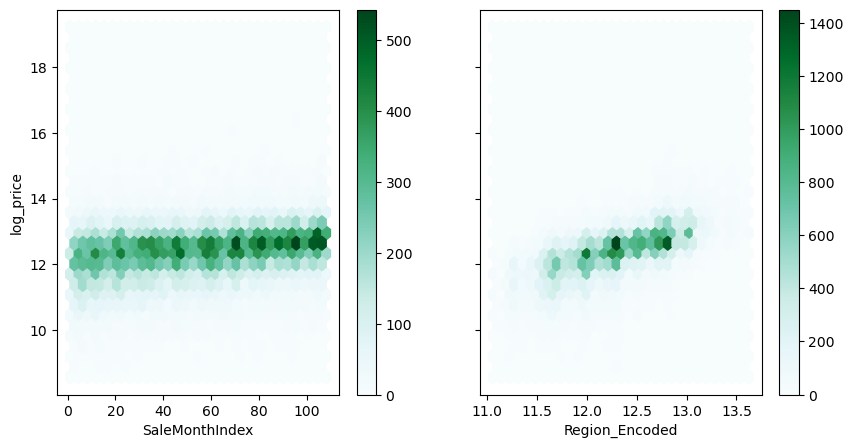

In [5]:
# As the number of samples is huge, it looks messy if we use scatter. So here we use hexbin plot to show the correlation for each continuous descriptive feature and target feature. 
fig, axs = plt.subplots(1, 2, sharey=True)
df.plot(kind='hexbin', x='SaleMonthIndex', y='log_price', gridsize=30,label="%.3f" %df[['SaleMonthIndex', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[0], figsize=(10, 5))
df.plot(kind='hexbin', x='Region_Encoded', y='log_price', gridsize=30,label="%.3f" %df[['Region_Encoded', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[1])

The color shows the density in the area. And the hexbin plots show that both SaleMonthIndex and Region_Encoded have a roughly linear relationship with Price.

## Preparing the data with temporal split.
As price is time related, we split the training data into 5 groups of training dataset and validation dataset by year.<br>
The first group: 2016-2019 for training, 2020 for validation.<br>
The second group: 2017-2020 for training, 2021 for validation.<br>
The third group: 2018-2021 for training, 2022 for validation.<br>
The fourth group: 2019-2022 for training, 2023 for validation.<br>
The fifth group: 2020-2023 for training, 2024 for validation.

In [6]:
# Define descriptive features and target feature
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
target_original = 'Price(€)'
target_log='log_price'


folds = []

# Define start_year, end_year and val_year (year for validation) of each group
group_configs = [
    (2016, 2019, 2020),
    (2017, 2020, 2021),
    (2018, 2021, 2022),
    (2019, 2022, 2023),
    (2020, 2023, 2024)
]

# start grouping
for i, (start_year, end_year, val_year) in enumerate(group_configs):
    # 1. pick out the samples of training data
    train_mask = (df['SaleYear'] >= start_year) & (df['SaleYear'] <= end_year)
    X_train = df.loc[train_mask, features]
    y_train_log = df.loc[train_mask, target_log]
    y_train_original=df.loc[train_mask, target_original]
    
    # 2. pick out the samples of validation data
    val_mask = df['SaleYear'] == val_year
    X_val = df.loc[val_mask, features]
    y_val_original = df.loc[val_mask, target_original]
    y_val_log = df.loc[val_mask, target_log]
    
    # 3. save the data set as dictionary and add into folds
    folds.append({
        'X_train': X_train,
        'y_train_log': y_train_log,
        'y_train_original': y_train_original,
        'X_val': X_val,
        'y_val_log': y_val_log,
        'y_val_original': y_val_original,
        'info': f"Group {i+1}: Train({start_year}-{end_year}) -> Val({val_year})"
    })
    
    print(f" {folds[i]['info']} | training data: {len(X_train)}, validation data: {len(X_val)}")

print("\nDone! Visiting the first group by folds[0]['X_train']")

 Group 1: Train(2016-2019) -> Val(2020) | training data: 23997, validation data: 6000
 Group 2: Train(2017-2020) -> Val(2021) | training data: 23998, validation data: 6000
 Group 3: Train(2018-2021) -> Val(2022) | training data: 23999, validation data: 6000
 Group 4: Train(2019-2022) -> Val(2023) | training data: 23999, validation data: 6000
 Group 5: Train(2020-2023) -> Val(2024) | training data: 24000, validation data: 5999

Done! Visiting the first group by folds[0]['X_train']


## Start modeling

### 

In [7]:
# This function is used repeatedly to compute, print and return the regression metrics
def getMetrics(testActualVal, predictions):
    mae=metrics.mean_absolute_error(testActualVal, predictions)
    rmse=metrics.mean_squared_error(testActualVal, predictions)**0.5
    r2=metrics.r2_score(testActualVal, predictions)
    print('\n==============================================================================')
    print("MAE: ", mae)
    #print("MSE: ", metrics.mean_squared_error(testActualVal, predictions))
    print("RMSE: ", rmse)
    print("R2: ", r2)
    return (mae,rmse,r2)

In [8]:
# Initialize variables for recording evaluation results
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
results=[]

In [9]:
# get baseline data
print('Baseline')

y=df[['Price(€)']]
baseline_pred = np.full(shape=y.shape[0], fill_value=y.mean())
(mae,rmse,r2)=getMetrics(y,baseline_pred)
results.append({
    'model':'Baseline',
    'MAE':mae,
    'RMSE':rmse,
    'R2':r2
})

Baseline

MAE:  194184.57136897265
RMSE:  1391583.1506862247
R2:  0.0


### 1 Modeling with LinearRegression

In [10]:
# write code here

### 2 Modeling with Lasso

In [11]:
# write code here

### 3 Modeling with RidgeCV

In [12]:
from sklearn.linear_model import RidgeCV
print("Ridge")
errors={
    'MAE':[],
    'RMSE':[],
    'R2':[]
    }
for fold in folds:
    # print the info of current group
    print('='*70)
    print(fold['info'])

    # pick out the dataset
    X_train=fold['X_train']
    y_train_log=fold['y_train_log']
    y_train_original=fold['y_train_original']
    X_val=fold['X_val']
    y_val_log=fold['y_val_log']
    y_val_original=fold['y_val_original']

    # train the model
    ridge = RidgeCV()
    ridge.fit(X_train, y_train_log)

    # Print the weights learned for each feature.
    print("\nIntercept: \n", ridge.intercept_)
    print("Features and coeficients:", list(zip(features, ridge.coef_))[:10])
  
    # Predicted price on validation set
    pred_log = ridge.predict(X_val)
    pred_original=np.expm1(pred_log)
    (mae,rmse,r2)=getMetrics(y_val_original, pred_original)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    feature_importance = pd.DataFrame({'feature': features, 'importance':ridge.coef_})
    display(feature_importance.sort_values('importance', ascending=False))

Ridge
Group 1: Train(2016-2019) -> Val(2020)

Intercept: 
 0.8199804255672216
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.4833779504850765)), ('VATExclusive', np.float64(0.13742076456988137)), ('SaleMonthIndex', np.float64(0.0019795962252797707)), ('Region_Encoded', np.float64(0.9334702002708692))]

MAE:  128024.17907390879
RMSE:  501341.50451158325
R2:  0.06690493116930007


,feature,importance
3,Region_Encoded,0.933470
1,VATExclusive,0.137421
2,SaleMonthIndex,0.001980
0,NotFullMarketPrice,-0.483378


Group 2: Train(2017-2020) -> Val(2021)

Intercept: 
 1.169024141243158
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.4887073863405733)), ('VATExclusive', np.float64(0.17354342319898353)), ('SaleMonthIndex', np.float64(-0.0010276936266316004)), ('Region_Encoded', np.float64(0.9125328331324868))]

MAE:  151829.82569494945
RMSE:  991407.592411982
R2:  0.01733039122149549


,feature,importance
3,Region_Encoded,0.912533
1,VATExclusive,0.173543
2,SaleMonthIndex,-0.001028
0,NotFullMarketPrice,-0.488707


Group 3: Train(2018-2021) -> Val(2022)

Intercept: 
 1.106309336366225
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5379870840306709)), ('VATExclusive', np.float64(0.1957599260012313)), ('SaleMonthIndex', np.float64(0.0007839650797759135)), ('Region_Encoded', np.float64(0.9112677991604112))]

MAE:  146554.9293914013
RMSE:  409664.03586947575
R2:  0.09706766706375147


,feature,importance
3,Region_Encoded,0.911268
1,VATExclusive,0.195760
2,SaleMonthIndex,0.000784
0,NotFullMarketPrice,-0.537987


Group 4: Train(2019-2022) -> Val(2023)

Intercept: 
 0.9056592419391691
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5446887802910562)), ('VATExclusive', np.float64(0.2070240513566551)), ('SaleMonthIndex', np.float64(0.0025177719131889444)), ('Region_Encoded', np.float64(0.9191537270733896))]

MAE:  171428.3833833925
RMSE:  1289792.231909225
R2:  0.01572509710852632


,feature,importance
3,Region_Encoded,0.919154
1,VATExclusive,0.207024
2,SaleMonthIndex,0.002518
0,NotFullMarketPrice,-0.544689


Group 5: Train(2020-2023) -> Val(2024)

Intercept: 
 1.0787851366130408
Features and coeficients: [('NotFullMarketPrice', np.float64(-0.5621726039870232)), ('VATExclusive', np.float64(0.21586142983302814)), ('SaleMonthIndex', np.float64(0.0013414527041959445)), ('Region_Encoded', np.float64(0.9096747163593797))]

MAE:  205034.02586201232
RMSE:  2935020.528956109
R2:  0.0041325404647043484


,feature,importance
3,Region_Encoded,0.909675
1,VATExclusive,0.215861
2,SaleMonthIndex,0.001341
0,NotFullMarketPrice,-0.562173


Intercept is the base value. Importance (coeficients)  of features means how much the feature contributes to the prediction. Take group 5 as an example:<br>

price=-58603.03464235173+36938.314172\*VATExclusive+246.619944\*SaleMonthIndex+1.195068\*Region_Encoded+-105837.143803\*NotFullMarketPrice<br>

1,VATExclusive:36938.314172. It means if the property is VATExclusive, it adds €36938.314172 to the base value.<br>

2,SaleMonthIndex: 246.619944. It means the price grows by €246.619944 by month.<br>

3,Region_Encoded: 1.195068. It means adding 1.195068 times of the Region_Encoded value (the average price of the region in last year) to the base value.<br>

4,NotFullMarketPrice:-105837.143803. It means if the property is NotFullMarketPrice, the price declines by €105837.143803<br>

In [13]:
print('MAE:',errors['MAE'])
print('RMSE:',errors['RMSE'])
print('R2:',errors['R2'])

mean_mae=sum(errors['MAE'])/len(errors['MAE'])
mean_rmse=sum(errors['RMSE'])/len(errors['RMSE'])
mean_r2=sum(errors['R2'])/len(errors['R2'])
results.append({
    'model':'RidgeCV',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print(results[-1])

MAE: [128024.17907390879, 151829.82569494945, 146554.9293914013, 171428.3833833925, 205034.02586201232]
RMSE: [501341.50451158325, 991407.592411982, 409664.03586947575, 1289792.231909225, 2935020.528956109]
R2: [0.06690493116930007, 0.01733039122149549, 0.09706766706375147, 0.01572509710852632, 0.0041325404647043484]
{'model': 'RidgeCV', 'MAE': 160574.26868113287, 'RMSE': 1225445.178731675, 'R2': 0.04023212540555554}


The performance of the model keeps stable on different groups . An average R2 of 0.04 means the model does not predict well, just similar to predicting with average.

### 4 Modeling with Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest")

# Store evaluation results for each fold
errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

# Store feature importance from each fold
rf_feature_importances = []

# Loop through each time-based fold
for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # Get training and validation data for this fold
    X_train = fold['X_train']
    y_train_log = fold['y_train_log']
    X_val = fold['X_val']
    y_val_original = fold['y_val_original']

    # Build Random Forest model
    # n_estimators: number of trees
    # max_depth: maximum depth of each tree
    # min_samples_split / min_samples_leaf: help reduce overfitting
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # Train model using log-transformed target
    rf_model.fit(X_train, y_train_log)

    # Predict log_price on validation set
    pred_log = rf_model.predict(X_val)

    # Convert predicted log_price back to original price
    # Use expm1 because log_price was likely created by np.log1p(price)
    pred_original = np.expm1(pred_log)

    # Evaluate predictions against original price
    mae, rmse, r2 = getMetrics(y_val_original, pred_original)

    # Save fold metrics
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Save feature importance for this fold
    rf_feature_importances.append(rf_model.feature_importances_)

# Print metrics from all folds
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average metrics across all folds
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])

# Save final averaged result into results list
results.append({
    'model': 'Random Forest',
    'MAE': mean_mae,
    'RMSE': mean_rmse,
    'R2': mean_r2
})

print("\nAverage Random Forest Performance:")
print(results[-1])

# Calculate average feature importance across all folds
mean_importance = np.mean(rf_feature_importances, axis=0)

rf_importance_df = pd.DataFrame({
    'feature': features,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

print("\nAverage Feature Importance (Random Forest):")
display(rf_importance_df)

Random Forest
Group 1: Train(2016-2019) -> Val(2020)

MAE:  130121.96284730427
RMSE:  505224.9754912797
R2:  0.052393137258030964
Group 2: Train(2017-2020) -> Val(2021)

MAE:  156248.18292718258
RMSE:  993893.0681683845
R2:  0.012397076046181676
Group 3: Train(2018-2021) -> Val(2022)

MAE:  149936.18124874565
RMSE:  412666.46007751033
R2:  0.0837840001924618
Group 4: Train(2019-2022) -> Val(2023)

MAE:  175040.56674982226
RMSE:  1289486.4183317784
R2:  0.01619179079337174
Group 5: Train(2020-2023) -> Val(2024)

MAE:  204895.22524142344
RMSE:  2938092.3478281386
R2:  0.0020468819286750817
MAE: [130121.96284730427, 156248.18292718258, 149936.18124874565, 175040.56674982226, 204895.22524142344]
RMSE: [505224.9754912797, 993893.0681683845, 412666.46007751033, 1289486.4183317784, 2938092.3478281386]
R2: [0.052393137258030964, 0.012397076046181676, 0.0837840001924618, 0.01619179079337174, 0.0020468819286750817]

Average Random Forest Performance:
{'model': 'Random Forest', 'MAE': 163248.4238

,feature,importance
3,Region_Encoded,0.822848
2,SaleMonthIndex,0.078706
0,NotFullMarketPrice,0.061003
1,VATExclusive,0.037443


The feature importance results indicate that Region_Encoded dominates the model, accounting for over 80% of the predictive power. This suggests that location is the primary factor influencing house prices in the dataset.

However, other features contribute very little, indicating limited feature diversity. This imbalance may explain the poor overall model performance (low R²), as the model relies heavily on a single feature and fails to capture other important factors.
This suggests that additional features are required to improve model performance.

### 5 Modeling with Pipeline

In [15]:
#code here